<a href="https://colab.research.google.com/github/Dayaanaly/U-Net-vs-SegNet/blob/main/UNet_vs_SegNet_Segmentaci%C3%B3n_Rodilla_Actualizada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto: Comparativa entre U-Net y SegNet para segmentación automática de rodilla**

*Centro Universitario de Ciencias Exactas e Ingenierías*\
*División de Tecnologías para la Integración Ciber-Humana*\
*Maestría en Ciencias en Róbotica e Inteligencia Artificial*
# ***********************************
<br>

Dr. Carlos Alberto Villaseñor Padilla\
26 de Mayo de 2026



**``NOMBRE:``**
Dayana Analy Pacheco Bañuelos\
**``CÓDIGO:``**
217535226

Instalar librería para archivos .nrrd

In [1]:
!pip install pynrrd

Montar Google Drive

In [2]:
from google.colab import drive
import os

# Si Drive ya está montado, no lo vuelve a montar
if os.path.exists('/content/drive/MyDrive'):
    print("Google Drive ya está montado.")
else:
    drive.mount('/content/drive')


Mounted at /content/drive


Librerías

In [3]:
#Librerias
# -------
import os
import time
import cv2
import nrrd
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model

Parámetros y directorios para rótula


In [4]:
# Directorios de imágenes y máscaras
image_dir = '/content/drive/MyDrive/Equipo Trifuerza/Datos/Data set grises/Dataset mezclado 2D'
mask_dir  = '/content/drive/MyDrive/Equipo Trifuerza/Datos/Data set grises/Mascaras mezcladas'

# Verificación rápida de rutas
print("Existe image_dir:", os.path.exists(image_dir))
print("Existe mask_dir:", os.path.exists(mask_dir))

if not os.path.exists(image_dir):
    raise FileNotFoundError(f"No existe la carpeta de imágenes: {image_dir}")

if not os.path.exists(mask_dir):
    raise FileNotFoundError(f"No existe la carpeta de máscaras: {mask_dir}")

# Parámetros de la imagen y segmentación
# ================================
IMG_HEIGHT = 320
IMG_WIDTH = 224
IMG_CHANNELS = 1      # Imágenes en escala de grises
NUM_CLASSES = 4       # clases: fondo, fémur, tibia, rótula
batch_size = 8


# ================================
# Parámetros ajustables del entrenamiento
# ================================
# Estos valores se usarán para entrenar tanto U-Net como SegNet
# con las mismas condiciones experimentales.

LEARNING_RATE = 5e-4      # Tasa de aprendizaje más estable que 0.001
EPOCHS = 60               # Número máximo de épocas
PATIENCE = 8              # Épocas de espera antes de detener si no mejora
SMOOTH = 1e-6             # Evita divisiones entre cero en Dice e IoU

# Dropout para la U-Net mejorada
DROPOUT_LOW = 0.10
DROPOUT_MID = 0.20
DROPOUT_DEEP = 0.30

# Semilla para reproducibilidad
SEED = 42

tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# Carpeta de resultados
# ================================
output_dir = '/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_60e'
os.makedirs(output_dir, exist_ok=True)

print("Los modelos y resultados se guardarán en:")
print(output_dir)

Existe image_dir: True
Existe mask_dir: True
Los modelos y resultados se guardarán en:
/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_60e


Preprocesamiento

Cantidad de imágenes: 200
Cantidad de máscaras: 200
Forma de images: (200, 320, 224, 1)
Forma de masks: (200, 320, 224, 1)
Valores únicos en masks: [0 1 2 3]
Imágenes entrenamiento: (160, 320, 224, 1)
Máscaras entrenamiento: (160, 320, 224, 1)
Imágenes validación: (40, 320, 224, 1)
Máscaras validación: (40, 320, 224, 1)


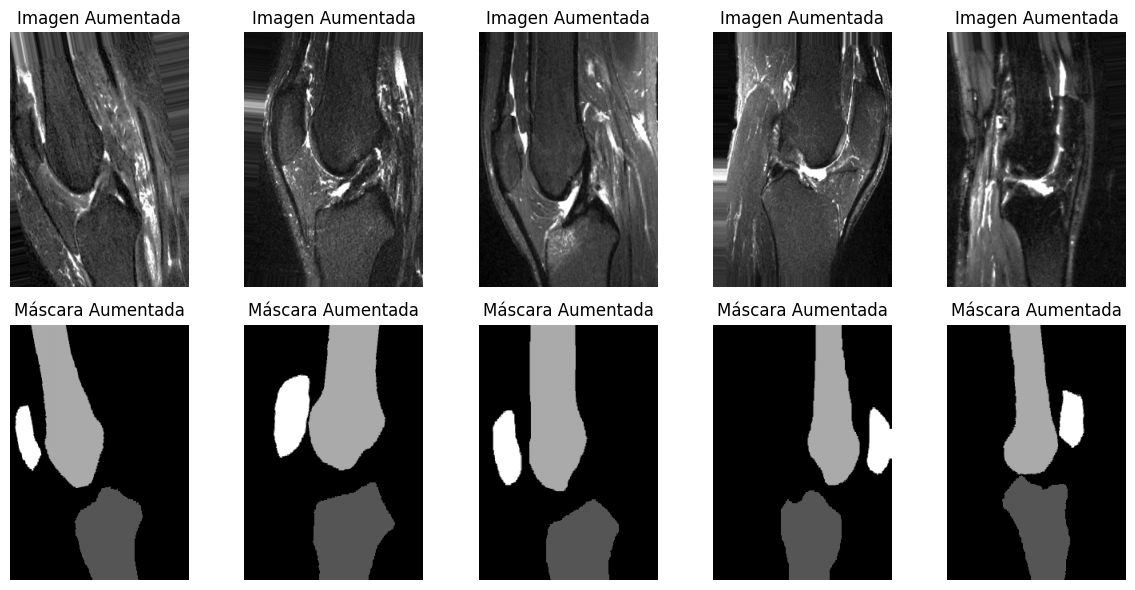

In [5]:
# Filtrar archivos válidos (.nrrd y .bmp)
# ================================
valid_extensions = ('.nrrd', '.bmp')

image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith(valid_extensions)
])

mask_files = sorted([
    f for f in os.listdir(mask_dir)
    if f.lower().endswith(valid_extensions)
])

print("Cantidad de imágenes:", len(image_files))
print("Cantidad de máscaras:", len(mask_files))

assert len(image_files) == len(mask_files), "La cantidad de imágenes y máscaras debe ser la misma"


# ================================
# Función personalizada para cargar imágenes
# ================================
def load_image_custom(filepath, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode='grayscale'):
    ext = os.path.splitext(filepath)[1].lower()

    if ext == '.nrrd':
        # Cargar usando la librería nrrd
        img_data, header = nrrd.read(filepath)

        # Dependiendo del color_mode, procesamos la imagen
        if color_mode == 'grayscale':
            # Si la imagen es a color, convertirla a escala de grises
            if img_data.ndim == 3 and img_data.shape[-1] > 1:
                img_data = np.mean(img_data, axis=-1)

            # Si queda una dimensión extra de canal, la eliminamos temporalmente
            if img_data.ndim == 3 and img_data.shape[-1] == 1:
                img_data = np.squeeze(img_data, axis=-1)

            # Redimensionar usando cv2
            img_resized = cv2.resize(img_data, (target_size[1], target_size[0]))

            # Agregar la dimensión del canal
            img_resized = np.expand_dims(img_resized, axis=-1)

            return img_resized

        elif color_mode == 'rgb':
            # Si es color, se espera que la imagen tenga 3 canales
            # En caso de tener una sola banda, se replicará
            if img_data.ndim == 2:
                img_data = np.stack((img_data,) * 3, axis=-1)

            img_resized = cv2.resize(img_data, (target_size[1], target_size[0]))

            return img_resized

        else:
            raise ValueError("Modo de color no soportado: " + color_mode)

    else:
        # Para otros formatos (.bmp), usamos load_img de Keras
        return img_to_array(
            load_img(filepath, target_size=target_size, color_mode=color_mode)
        )


# ================================
# Cargar y preprocesar imágenes y máscaras
# ================================
images = []
masks = []

for img_file, msk_file in zip(image_files, mask_files):
    image_path = os.path.join(image_dir, img_file)
    mask_path  = os.path.join(mask_dir, msk_file)

    # Cargar la imagen y normalizar valores entre 0 y 1
    img = load_image_custom(
        image_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        color_mode='grayscale'
    )

    img = img.astype('float32') / 255.0

    # Cargar la máscara
    # La máscara contiene índices de clase: 0, 1, 2, 3
    mask = load_image_custom(
        mask_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        color_mode='grayscale'
    )

    mask = mask.astype(np.int64)

    # Si la máscara trae canal extra, lo quitamos para trabajar en 2D
    if mask.ndim == 3 and mask.shape[-1] == 1:
        mask = np.squeeze(mask, axis=-1)

    # Rotar la máscara para corregir orientación
    mask = np.rot90(mask, k=3, axes=(0, 1))  # 90° horario

    # Redimensionar con INTER_NEAREST para conservar etiquetas enteras
    mask = cv2.resize(
        mask,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_NEAREST
    )

    # VOLTEO HORIZONTAL para corregir el “espejo”
    mask = np.fliplr(mask)

    # Agregar la dimensión del canal para que la máscara tenga forma (alto, ancho, 1)
    mask = np.expand_dims(mask, axis=-1)

    images.append(img)
    masks.append(mask)


# ================================
# Convertir listas a arrays de NumPy
# ================================
images = np.array(images)
masks  = np.array(masks)

# Verificación y corrección de dimensiones
# images → (N, 320, 224, 1)
# masks  → (N, 320, 224, 1)
if masks.ndim == 5:
    masks = np.squeeze(masks, axis=-1)

# Asegurar que las máscaras estén en formato entero
masks = masks.astype(np.int32)

# Limitar valores al rango correcto
masks = np.clip(masks, 0, NUM_CLASSES - 1)

print("Forma de images:", images.shape)
print("Forma de masks:", masks.shape)
print("Valores únicos en masks:", np.unique(masks))


# ================================
# Dividir en conjuntos de entrenamiento y validación
# ================================
# 80% entrenamiento, 20% validación

images_train, images_val, masks_train, masks_val = train_test_split(
    images,
    masks,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)

print("Imágenes entrenamiento:", images_train.shape)
print("Máscaras entrenamiento:", masks_train.shape)
print("Imágenes validación:", images_val.shape)
print("Máscaras validación:", masks_val.shape)


# ================================
# Crear generadores de datos con aumento (augmentation)
# ================================
data_gen_args = dict(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generadores
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen  = ImageDataGenerator(**data_gen_args)

# Ajuste no estrictamente necesario, pero útil si algún escalador lo requiere
image_datagen.fit(images_train, augment=True, seed=SEED)
mask_datagen.fit(masks_train,  augment=True, seed=SEED)


def crear_train_generator():
    """
    Crea un generador sincronizado para imágenes y máscaras.

    Se usa la misma semilla para que las transformaciones aplicadas
    a la imagen también se apliquen a su máscara correspondiente.
    """

    train_img_gen = image_datagen.flow(
        images_train,
        batch_size=batch_size,
        seed=SEED
    )

    train_mask_gen = mask_datagen.flow(
        masks_train,
        batch_size=batch_size,
        seed=SEED
    )

    while True:
        imgs = next(train_img_gen)
        msks = next(train_mask_gen)

        # ================================
        # Corrección importante para máscaras
        # ================================
        # Las máscaras son etiquetas enteras:
        # 0 = fondo
        # 1 = fémur
        # 2 = tibia
        # 3 = rótula
        #
        # Después del aumento de datos pueden aparecer valores decimales,
        # por eso redondeamos y limitamos el rango.
        msks = np.rint(msks).astype(np.int32)
        msks = np.clip(msks, 0, NUM_CLASSES - 1)

        yield imgs, msks


# ================================
# Visualizar algunas imágenes y máscaras aumentadas
# ================================
batch = next(crear_train_generator())

plt.figure(figsize=(12, 6))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(batch[0][i].squeeze(), cmap='gray')
    plt.title("Imagen Aumentada")
    plt.axis('off')

    plt.subplot(2, 5, i + 6)
    plt.imshow(batch[1][i].squeeze(), cmap='gray')
    plt.title("Máscara Aumentada")
    plt.axis('off')

plt.tight_layout()
plt.show()


Definición de la U-Net multiclase


*   Métricas + modelo



In [10]:
#U-Net

# Métricas de segmentación
# ================================
# A diferencia de accuracy, Dice e IoU evalúan qué tan bien coinciden
# las regiones segmentadas con las máscaras reales.

def preparar_y_true(y_true):
    """
    Prepara la máscara real para las métricas y la función de pérdida.

    Entrada esperada:
    y_true: (batch, H, W, 1)

    Salida:
    y_true: (batch, H, W)
    """

    y_true = tf.cast(y_true, tf.int32)

    # Quitamos el canal extra de la máscara
    if y_true.shape.rank == 4:
        y_true = tf.squeeze(y_true, axis=-1)

    return y_true


def mean_dice(y_true, y_pred):
    """
    Dice promedio para segmentación multiclase.

    Dice mide el solapamiento entre la máscara real y la predicha.
    Un valor cercano a 1 indica mejor segmentación.
    """

    y_true = preparar_y_true(y_true)

    # Convertimos la máscara real a one-hot
    y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)

    # y_pred ya viene como probabilidades por softmax
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_one_hot = tf.cast(y_true_one_hot, tf.float32)

    # Calculamos Dice por clase
    axes = [0, 1, 2]

    intersection = tf.reduce_sum(y_true_one_hot * y_pred, axis=axes)
    denominator = tf.reduce_sum(y_true_one_hot + y_pred, axis=axes)

    dice = (2.0 * intersection + SMOOTH) / (denominator + SMOOTH)

    # Ignoramos la clase 0 si representa fondo
    # Promediamos solo clases anatómicas: 1, 2 y 3
    dice_foreground = dice[1:]

    return tf.reduce_mean(dice_foreground)


def mean_iou(y_true, y_pred):
    """
    IoU promedio para segmentación multiclase.

    IoU mide la intersección sobre la unión entre la máscara real y la predicha.
    Un valor cercano a 1 indica mejor segmentación.
    """

    y_true = preparar_y_true(y_true)

    # Convertimos la máscara real a one-hot
    y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)

    y_pred = tf.cast(y_pred, tf.float32)
    y_true_one_hot = tf.cast(y_true_one_hot, tf.float32)

    axes = [0, 1, 2]

    intersection = tf.reduce_sum(y_true_one_hot * y_pred, axis=axes)
    union = tf.reduce_sum(y_true_one_hot + y_pred, axis=axes) - intersection

    iou = (intersection + SMOOTH) / (union + SMOOTH)

    # Ignoramos fondo y promediamos fémur, tibia y rótula
    iou_foreground = iou[1:]

    return tf.reduce_mean(iou_foreground)


def sparse_ce_dice_loss(y_true, y_pred):
    """
    Función de pérdida combinada:
    Sparse Categorical Crossentropy + Dice Loss.

    Sparse Categorical Crossentropy:
    - Ayuda a clasificar correctamente cada pixel.

    Dice Loss:
    - Ayuda a mejorar el solapamiento de las regiones segmentadas.
    - Es útil cuando hay mucho fondo y las estructuras son pequeñas.
    """

    y_true_prepared = preparar_y_true(y_true)

    # Pérdida clásica para segmentación multiclase con etiquetas enteras
    ce = tf.keras.losses.sparse_categorical_crossentropy(
        y_true_prepared,
        y_pred
    )

    ce = tf.reduce_mean(ce)

    # Dice Loss = 1 - Dice
    dice_loss = 1.0 - mean_dice(y_true, y_pred)

    # Combinamos ambas pérdidas
    total_loss = ce + dice_loss

    return total_loss

# Bloque de convolución para U-Net
# ================================
# Este bloque reemplaza las dos Conv2D repetidas en cada nivel.
# Mantiene la estructura original, pero agrega:
# - BatchNormalization para estabilizar el entrenamiento
# - SpatialDropout2D para reducir sobreajuste

def conv_block(x, filters, dropout_rate=0.0, block_name=""):
    """
    Bloque básico de la U-Net:
    Conv2D -> BatchNormalization -> ReLU
    Conv2D -> BatchNormalization -> ReLU
    SpatialDropout2D opcional
    """

    # Primera convolución
    x = layers.Conv2D(
        filters,
        3,
        padding='same',
        kernel_initializer='he_normal',
        name=f'{block_name}_conv1'
    )(x)

    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu1')(x)

    # Segunda convolución
    x = layers.Conv2D(
        filters,
        3,
        padding='same',
        kernel_initializer='he_normal',
        name=f'{block_name}_conv2'
    )(x)

    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu2')(x)

    # Dropout espacial: apaga mapas de características completos
    # Es más adecuado para CNN que Dropout normal
    if dropout_rate > 0:
        x = layers.SpatialDropout2D(
            dropout_rate,
            name=f'{block_name}_spatial_dropout'
        )(x)

    return x

# Definir la U-Net para segmentación multi-clase
# ================================
def U_net(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=NUM_CLASSES):
    inputs = tf.keras.Input(shape=input_shape)

    # ================================
    # Encoder / Camino descendente
    # ================================
    # Aquí la red reduce la resolución y aprende características:
    # bordes, texturas, contornos y patrones anatómicos.

    # Bloque Down 1
    conv1 = conv_block(inputs, 64, dropout_rate=DROPOUT_LOW, block_name="unet_down1")
    pool1 = layers.MaxPooling2D((2, 2), name="unet_pool1")(conv1)

    # Bloque Down 2
    conv2 = conv_block(pool1, 128, dropout_rate=DROPOUT_LOW, block_name="unet_down2")
    pool2 = layers.MaxPooling2D((2, 2), name="unet_pool2")(conv2)

    # Bloque Down 3
    conv3 = conv_block(pool2, 256, dropout_rate=DROPOUT_MID, block_name="unet_down3")
    pool3 = layers.MaxPooling2D((2, 2), name="unet_pool3")(conv3)

    # ================================
    # Bloque intermedio / Bottleneck
    # ================================
    # Es la parte más profunda de la red.
    # Aquí aprende características más abstractas de la rodilla.
    conv4 = conv_block(pool3, 512, dropout_rate=DROPOUT_DEEP, block_name="unet_bottleneck")

    # ================================
    # Decoder / Camino ascendente
    # ================================
    # Aquí la red recupera resolución para construir la máscara final.
    # Las concatenaciones conservan detalles finos del encoder.

    # Up 1
    up1 = layers.UpSampling2D((2, 2), name="unet_up1_sampling")(conv4)

    up1 = layers.Conv2D(
        256,
        2,
        padding='same',
        kernel_initializer='he_normal',
        activation='relu',
        name="unet_up1_conv"
    )(up1)

    # Conexión tipo puente con conv3
    concat1 = layers.concatenate([up1, conv3], name="unet_concat1")
    conv5 = conv_block(concat1, 256, dropout_rate=DROPOUT_MID, block_name="unet_up1")

    # Up 2
    up2 = layers.UpSampling2D((2, 2), name="unet_up2_sampling")(conv5)

    up2 = layers.Conv2D(
        128,
        2,
        padding='same',
        kernel_initializer='he_normal',
        activation='relu',
        name="unet_up2_conv"
    )(up2)

    # Conexión tipo puente con conv2
    concat2 = layers.concatenate([up2, conv2], name="unet_concat2")
    conv6 = conv_block(concat2, 128, dropout_rate=DROPOUT_LOW, block_name="unet_up2")

    # Up 3
    up3 = layers.UpSampling2D((2, 2), name="unet_up3_sampling")(conv6)

    up3 = layers.Conv2D(
        64,
        2,
        padding='same',
        kernel_initializer='he_normal',
        activation='relu',
        name="unet_up3_conv"
    )(up3)

    # Conexión tipo puente con conv1
    concat3 = layers.concatenate([up3, conv1], name="unet_concat3")
    conv7 = conv_block(concat3, 64, dropout_rate=0.0, block_name="unet_up3")

    # ================================
    # Capa de salida
    # ================================
    # NUM_CLASSES canales con softmax.
    # Para cada pixel, la red calcula la probabilidad de pertenecer a cada clase:
    # 0 = fondo
    # 1 = fémur
    # 2 = tibia
    # 3 = rótula
    outputs = layers.Conv2D(
        num_classes,
        1,
        activation='softmax',
        name="unet_segmentation_output"
    )(conv7)

    model = models.Model(inputs, outputs, name="U_Net_Rodilla_Multiclase")

    return model

Definición de SegNet multiclase

In [14]:
# ================================
# Definición de SegNet / SegNet-like multiclase
# ================================
def segnet_conv_block(x, filters, block_name=""):
    """
    Bloque básico de SegNet:
    Conv2D -> BatchNormalization -> ReLU
    Conv2D -> BatchNormalization -> ReLU

    A diferencia de U-Net, aquí no se guardan conexiones de salto
    para concatenarlas en el decoder.
    """

    # Primera convolución
    x = layers.Conv2D(
        filters,
        3,
        padding='same',
        kernel_initializer='he_normal',
        name=f'{block_name}_conv1'
    )(x)

    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu1')(x)

    # Segunda convolución
    x = layers.Conv2D(
        filters,
        3,
        padding='same',
        kernel_initializer='he_normal',
        name=f'{block_name}_conv2'
    )(x)

    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu2')(x)

    return x


def SegNet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=NUM_CLASSES):
    """
    Arquitectura tipo SegNet para segmentación multiclase.

    Diferencia principal con U-Net:
    - SegNet usa encoder-decoder.
    - No concatena características del encoder con el decoder.
    - Esto permite comparar si las conexiones de salto de U-Net
      ayudan a mejorar los detalles de la segmentación.
    """

    inputs = tf.keras.Input(shape=input_shape)

    # ================================
    # Encoder / Camino descendente
    # ================================
    # Reduce la resolución y aprende características de la imagen.

    # Bloque Encoder 1
    enc1 = segnet_conv_block(inputs, 64, block_name="segnet_encoder1")
    pool1 = layers.MaxPooling2D((2, 2), name="segnet_pool1")(enc1)

    # Bloque Encoder 2
    enc2 = segnet_conv_block(pool1, 128, block_name="segnet_encoder2")
    pool2 = layers.MaxPooling2D((2, 2), name="segnet_pool2")(enc2)

    # Bloque Encoder 3
    enc3 = segnet_conv_block(pool2, 256, block_name="segnet_encoder3")
    pool3 = layers.MaxPooling2D((2, 2), name="segnet_pool3")(enc3)

    # ================================
    # Bottleneck
    # ================================
    # Representación más profunda de la imagen.
    bottleneck = segnet_conv_block(pool3, 512, block_name="segnet_bottleneck")

    # ================================
    # Decoder / Camino ascendente
    # ================================
    # Recupera la resolución para formar la máscara.
    # No usa concatenaciones con el encoder.

    # Bloque Decoder 1
    up1 = layers.UpSampling2D((2, 2), name="segnet_up1_sampling")(bottleneck)
    dec1 = segnet_conv_block(up1, 256, block_name="segnet_decoder1")

    # Bloque Decoder 2
    up2 = layers.UpSampling2D((2, 2), name="segnet_up2_sampling")(dec1)
    dec2 = segnet_conv_block(up2, 128, block_name="segnet_decoder2")

    # Bloque Decoder 3
    up3 = layers.UpSampling2D((2, 2), name="segnet_up3_sampling")(dec2)
    dec3 = segnet_conv_block(up3, 64, block_name="segnet_decoder3")

    # ================================
    # Capa de salida
    # ================================
    # Softmax genera una probabilidad por clase para cada pixel.
    outputs = layers.Conv2D(
        num_classes,
        1,
        activation='softmax',
        name="segnet_segmentation_output"
    )(dec3)

    model = models.Model(inputs, outputs, name="SegNet_Rodilla_Multiclase")

    return model


# ================================
# Función para compilar modelos
# ================================
# Esta función asegura que U-Net y SegNet usen:
# - mismo optimizador
# - misma pérdida
# - mismas métricas

def compilar_modelo(model):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=sparse_ce_dice_loss,
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name='pixel_accuracy'),
            mean_dice,
            mean_iou
        ]
    )

    return model

Funciones

In [15]:
# ================================
# Función general para entrenar modelos
# ================================
def entrenar_modelo(model, nombre_modelo):
    """
    Entrena un modelo de segmentación y guarda:
    - mejor modelo
    - modelo final
    - historial de entrenamiento en CSV
    """

    print("\n==============================")
    print("Entrenando modelo:", nombre_modelo)
    print("==============================\n")

    # Rutas de guardado
    checkpoint_path = os.path.join(output_dir, f'{nombre_modelo}_best_1.keras')
    final_model_path = os.path.join(output_dir, f'{nombre_modelo}_final_1.keras')
    history_path = os.path.join(output_dir, f'{nombre_modelo}_history_1.csv')

    # ================================
    # Callbacks
    # ================================

    checkpoint_cb = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_mean_dice',
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor='val_mean_dice',
        patience=PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

Configuración entrenamiento

In [16]:
# Configuración de pasos de entrenamiento
    # ================================
steps_per_epoch = max(1, len(images_train) // batch_size)
print("Steps per epoch:", steps_per_epoch)
print("Total entrenamiento:", len(images_train))
print("Total validación:", len(images_val))


Steps per epoch: 20
Total entrenamiento: 160
Total validación: 40


Entrenamiento

In [17]:
    # Entrenamiento
    # ================================
history = model.fit(
      crear_train_generator(),
      steps_per_epoch=steps_per_epoch,
      epochs=EPOCHS,
      validation_data=(images_val, masks_val),
      validation_steps=None,
      callbacks=[checkpoint_cb, early_stop, reduce_lr]
    )

    # ================================
    # Guardar modelo final
    # ================================
model.save(final_model_path)

    # ================================
    # Guardar historial como CSV
    # ================================
history_df = pd.DataFrame(history.history)
history_df.to_csv(history_path, index=False)

print("\nModelo final guardado en:", final_model_path)
print("Mejor modelo guardado en:", checkpoint_path)
print("Historial guardado en:", history_path)

return model, history, checkpoint_path, final_model_path

NameError: name 'model' is not defined

Entrenar U-Net

In [ ]:
# ================================
# Entrenar U-Net mejorada
# ================================
tf.keras.utils.set_random_seed(SEED)

model_unet = U_net()
model_unet = compilar_modelo(model_unet)

model_unet.summary()

model_unet, history_unet, unet_best_path, unet_final_path = entrenar_modelo(
    model_unet,
    nombre_modelo="UNet_Mejorada_actual"
)



Entrenar SegNet

In [ ]:
# ================================
# Entrenar SegNet
# ================================
tf.keras.utils.set_random_seed(SEED)

model_segnet = SegNet()
model_segnet = compilar_modelo(model_segnet)

model_segnet.summary()

model_segnet, history_segnet, segnet_best_path, segnet_final_path = entrenar_modelo(
    model_segnet,
    nombre_modelo="SegNet_actual"
)

Evaluación comparativa U-Net vs SegNet

In [ ]:
# ================================
# Evaluación comparativa
# ================================
def evaluar_modelo(model, nombre_modelo):
    """
    Evalúa el modelo en el conjunto de validación.
    Devuelve las métricas principales.
    """

    results = model.evaluate(images_val, masks_val, verbose=1, return_dict=True)

    metricas = {
        "Modelo": nombre_modelo
    }

    for name, value in results.items():
        metricas[name] = value

    return metricas


resultados_unet = evaluar_modelo(model_unet, "U-Net mejorada")
resultados_segnet = evaluar_modelo(model_segnet, "SegNet")

tabla_resultados = pd.DataFrame([resultados_unet, resultados_segnet])

print("\nTabla comparativa:")
display(tabla_resultados)

# Guardar tabla comparativa
tabla_resultados_path = os.path.join(output_dir, 'tabla_comparativa_resultados.csv')
tabla_resultados.to_csv(tabla_resultados_path, index=False)

print("Tabla comparativa guardada en:")
print(tabla_resultados_path)

# ================================
# Métricas por clase: Dice e IoU
# ================================
def metricas_por_clase(model, images, masks, nombre_modelo):
    """
    Calcula Dice e IoU por cada clase anatómica.
    Se ignora la clase 0 porque es fondo.
    """

    preds = model.predict(images, verbose=1)
    preds_classes = np.argmax(preds, axis=-1)

    true_classes = np.squeeze(masks)

    class_names = {
        1: "Fémur",
        2: "Tibia",
        3: "Rótula"
    }

    resultados = []

    for cls in range(1, NUM_CLASSES):
        pred_cls = (preds_classes == cls)
        true_cls = (true_classes == cls)

        intersection = np.logical_and(pred_cls, true_cls).sum()
        union = np.logical_or(pred_cls, true_cls).sum()

        pred_sum = pred_cls.sum()
        true_sum = true_cls.sum()

        dice = (2 * intersection + SMOOTH) / (pred_sum + true_sum + SMOOTH)
        iou = (intersection + SMOOTH) / (union + SMOOTH)

        resultados.append({
            "Modelo": nombre_modelo,
            "Clase": class_names.get(cls, f"Clase {cls}"),
            "Dice": dice,
            "IoU": iou
        })

    return resultados


metricas_clases = []

metricas_clases += metricas_por_clase(
    model_unet,
    images_val,
    masks_val,
    "U-Net mejorada"
)

metricas_clases += metricas_por_clase(
    model_segnet,
    images_val,
    masks_val,
    "SegNet"
)

tabla_clases = pd.DataFrame(metricas_clases)

print("\nMétricas por clase:")
display(tabla_clases)

# Guardar métricas por clase
tabla_clases_path = os.path.join(output_dir, 'tabla_metricas_por_clase.csv')
tabla_clases.to_csv(tabla_clases_path, index=False)

print("Métricas por clase guardadas en:")
print(tabla_clases_path)

Comparativa tiempo

In [ ]:
# ================================
# Medición de tiempo de inferencia
# ================================
def medir_tiempo_inferencia(model, images, nombre_modelo, num_repeticiones=20):
    """
    Mide el tiempo promedio que tarda el modelo en segmentar una imagen.
    """

    sample = images[:1]

    # Calentamiento
    _ = model.predict(sample, verbose=0)

    tiempos = []

    for _ in range(num_repeticiones):
        inicio = time.time()
        _ = model.predict(sample, verbose=0)
        fin = time.time()

        tiempos.append(fin - inicio)

    tiempo_promedio = np.mean(tiempos)

    return {
        "Modelo": nombre_modelo,
        "Tiempo promedio por imagen (s)": tiempo_promedio,
        "Tiempo promedio por imagen (ms)": tiempo_promedio * 1000
    }


tiempo_unet = medir_tiempo_inferencia(
    model_unet,
    images_val,
    "U-Net mejorada"
)

tiempo_segnet = medir_tiempo_inferencia(
    model_segnet,
    images_val,
    "SegNet"
)

tabla_tiempos = pd.DataFrame([tiempo_unet, tiempo_segnet])

print("\nTiempo de inferencia:")
display(tabla_tiempos)

# Guardar tabla de tiempos
tabla_tiempos_path = os.path.join(output_dir, 'tabla_tiempos_inferencia.csv')
tabla_tiempos.to_csv(tabla_tiempos_path, index=False)

print("Tiempos de inferencia guardados en:")
print(tabla_tiempos_path)


  Graficas de entrenamiento

In [ ]:
# ================================
# Graficar curvas de entrenamiento de U-Net
# ================================
plt.figure(figsize=(16, 10))

# Pérdida
plt.subplot(2, 2, 1)
plt.plot(history_unet.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history_unet.history['val_loss'], label='Pérdida Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('U-Net - Evolución de la pérdida')
plt.legend()

# Exactitud por pixel
plt.subplot(2, 2, 2)
plt.plot(history_unet.history['pixel_accuracy'], label='Pixel Accuracy Entrenamiento')
plt.plot(history_unet.history['val_pixel_accuracy'], label='Pixel Accuracy Validación')
plt.xlabel('Época')
plt.ylabel('Pixel Accuracy')
plt.title('U-Net - Exactitud por pixel')
plt.legend()

# Dice
plt.subplot(2, 2, 3)
plt.plot(history_unet.history['mean_dice'], label='Dice Entrenamiento')
plt.plot(history_unet.history['val_mean_dice'], label='Dice Validación')
plt.xlabel('Época')
plt.ylabel('Dice')
plt.title('U-Net - Dice promedio')
plt.legend()

# IoU
plt.subplot(2, 2, 4)
plt.plot(history_unet.history['mean_iou'], label='IoU Entrenamiento')
plt.plot(history_unet.history['val_mean_iou'], label='IoU Validación')
plt.xlabel('Época')
plt.ylabel('IoU')
plt.title('U-Net - IoU promedio')
plt.legend()

plt.tight_layout()

grafica_unet_path = os.path.join(output_dir, 'graficas_unet_mejorada.png')
plt.savefig(grafica_unet_path, dpi=300, bbox_inches='tight')

plt.show()

print("Gráficas de U-Net guardadas en:")
print(grafica_unet_path)


# ================================
# Graficar curvas de entrenamiento de SegNet
# ================================
plt.figure(figsize=(16, 10))

# Pérdida
plt.subplot(2, 2, 1)
plt.plot(history_segnet.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history_segnet.history['val_loss'], label='Pérdida Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('SegNet - Evolución de la pérdida')
plt.legend()

# Exactitud por pixel
plt.subplot(2, 2, 2)
plt.plot(history_segnet.history['pixel_accuracy'], label='Pixel Accuracy Entrenamiento')
plt.plot(history_segnet.history['val_pixel_accuracy'], label='Pixel Accuracy Validación')
plt.xlabel('Época')
plt.ylabel('Pixel Accuracy')
plt.title('SegNet - Exactitud por pixel')
plt.legend()

# Dice
plt.subplot(2, 2, 3)
plt.plot(history_segnet.history['mean_dice'], label='Dice Entrenamiento')
plt.plot(history_segnet.history['val_mean_dice'], label='Dice Validación')
plt.xlabel('Época')
plt.ylabel('Dice')
plt.title('SegNet - Dice promedio')
plt.legend()

# IoU
plt.subplot(2, 2, 4)
plt.plot(history_segnet.history['mean_iou'], label='IoU Entrenamiento')
plt.plot(history_segnet.history['val_mean_iou'], label='IoU Validación')
plt.xlabel('Época')
plt.ylabel('IoU')
plt.title('SegNet - IoU promedio')
plt.legend()

plt.tight_layout()

grafica_segnet_path = os.path.join(output_dir, 'graficas_segnet.png')
plt.savefig(grafica_segnet_path, dpi=300, bbox_inches='tight')

plt.show()

print("Gráficas de SegNet guardadas en:")
print(grafica_segnet_path)


Compartiva visual U-Net vs SegNet

In [ ]:
# ================================
# Comparación visual U-Net vs SegNet
# ================================
# Imagen original | Máscara real | U-Net mejorada | SegNet

num_samples = 4

sample_images = images_val[:num_samples]
sample_masks = masks_val[:num_samples]

# Predicciones U-Net
preds_unet = model_unet.predict(sample_images)
preds_unet_classes = np.argmax(preds_unet, axis=-1)

# Predicciones SegNet
preds_segnet = model_segnet.predict(sample_images)
preds_segnet_classes = np.argmax(preds_segnet, axis=-1)

# Máscaras reales
true_classes = np.squeeze(sample_masks)

plt.figure(figsize=(18, num_samples * 4))

for i in range(num_samples):
    # Imagen original
    plt.subplot(num_samples, 4, i * 4 + 1)
    plt.imshow(sample_images[i].squeeze(), cmap='gray')
    plt.title('Imagen original')
    plt.axis('off')

    # Máscara real
    plt.subplot(num_samples, 4, i * 4 + 2)
    plt.imshow(
        true_classes[i],
        cmap='nipy_spectral',
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    plt.title('Máscara real')
    plt.axis('off')

    # U-Net mejorada
    plt.subplot(num_samples, 4, i * 4 + 3)
    plt.imshow(
        preds_unet_classes[i],
        cmap='nipy_spectral',
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    plt.title('U-Net mejorada')
    plt.axis('off')

    # SegNet
    plt.subplot(num_samples, 4, i * 4 + 4)
    plt.imshow(
        preds_segnet_classes[i],
        cmap='nipy_spectral',
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    plt.title('SegNet')
    plt.axis('off')

plt.tight_layout()

comparacion_visual_path = os.path.join(output_dir, 'comparacion_visual_unet_vs_segnet.png')
plt.savefig(comparacion_visual_path, dpi=300, bbox_inches='tight')

plt.show()

print("Comparación visual guardada en:")
print(comparacion_visual_path)



Guardar datos modelos entrenados

In [ ]:

# Cargar modelos guardados después, si se necesita
# ================================
# Como los modelos usan pérdida y métricas personalizadas,
# al cargarlos se deben pasar en custom_objects.

custom_objects_dict = {
    'sparse_ce_dice_loss': sparse_ce_dice_loss,
    'mean_dice': mean_dice,
    'mean_iou': mean_iou
}

print("\nRutas importantes:")
print("Mejor U-Net:", unet_best_path)
print("Modelo final U-Net:", unet_final_path)
print("Mejor SegNet:", segnet_best_path)
print("Modelo final SegNet:", segnet_final_path)

print("\nProceso terminado correctamente.")